<a href="https://colab.research.google.com/github/ArlethSosa/Aeromexico/blob/main/Aeromexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Experience 2024**

Resultados y hallazgos de la experiencia de clientes 2024

1. Cargar datos
2. Exploración de datos


## 1. Cargar datos

In [ ]:
import pandas as pd

df = pd.read_excel("Base.xlsx", parse_dates=["fecha"])
df_rutas = pd.read_csv("cat_rutas.csv")

## 2. Exploración de datos

### Vista general de dataset

In [ ]:
df.head()

,fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,...,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora
0,2024-08-14,70072332,ORD,MEX,NaN,ORD,MEX,683,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
1,2024-04-21,65183802,MEX,FCO,FCO,MEX,NaN,70,AM,B787-800,...,5.0,5.0,4.0,3.0,5.0,3.0,3.0,NaN,5.0,NaN
2,2024-09-12,71347018,LAX,GDL,NaN,LAX,GDL,783,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
3,2024-06-18,67680750,MEX,ORD,NaN,MEX,ORD,1686,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,4.0,NaN,NaN,NaN,NaN
4,2024-08-17,70239655,CUN,MEX,NaN,CUN,MEX,551,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0,NaN,NaN


In [ ]:
df.shape

(6000, 26)

El dataset tiene 6000 filas y 26 columnas.

In [ ]:
df.dtypes

,0
fecha,datetime64[ns]
surveyid,int64
ato_origen,object
ato_destino,object
ato_conexion,object
ato_checkin,object
ato_equipaje,object
numerovuelo,int64
carrier,object
equipo,object


In [ ]:
df_rutas.shape

(272, 2)

In [ ]:
df_rutas.head()

,Ruta,Region_ruta
0,ACAMEX,Nacional
1,AGUMEX,Nacional
2,BJXMEX,Nacional
3,BJXMTY,Nacional
4,CENMEX,Nacional


Opciones de variables categoricas

In [ ]:
# Equipo
df["equipo"].unique()

array(['B737-800', 'B787-800', 'E190', 'B787-900', 'B737-8 MAX'],
      dtype=object)

In [ ]:
# Clase de cabina
df["clasecabina"].unique()

array(['Turista', 'Premier'], dtype=object)

In [ ]:
# Alimento
df["tipoalimento"].unique()

array(['snack', 'alimento'], dtype=object)

In [ ]:
# Carrier
df['carrier'].unique()

array(['AM', '5D'], dtype=object)

In [ ]:
# Canal check in
df["canalcheckin"].unique()

array(['Aeromexico.com', 'Aplicacion movil', 'Mostrador', 'Auto',
       'App 2.0', 'AeromÃ©xico.com', 'Quiosco', 'AplicaciÃ³n mÃ³vil',
       'App', 'Web', 'Counter', 'Kiosk'], dtype=object)

### Tratamiento básico de datos (Homologar canal cjeck in, agregar ruta y region)

- Homologar canales de check in

In [ ]:
df["canalcheckin"]=df["canalcheckin"].replace(["Aeromexico.com","AeromÃ©xico.com","Web"], "Página Web")
df['canalcheckin'] = df['canalcheckin'].replace(["Aplicacion movil", "App 2.0", "AplicaciÃ³n mÃ³vil", "App"], "Aplicación movil")
df['canalcheckin'] = df['canalcheckin'].replace("Counter", "Mostrador")
df['canalcheckin'] = df['canalcheckin'].replace(["Auto", "Kiosk"], "Quiosco")

In [ ]:
df['canalcheckin'].unique()

array(['Página Web', 'Aplicación movil', 'Mostrador', 'Quiosco'],
      dtype=object)

- Unir datasets

In [ ]:
# Nueva colunma de ruta
df['Ruta'] = df['ato_origen'] + df['ato_destino']


In [ ]:
# Asignar valor de región
df = df.merge(df_rutas, on="Ruta", how="left")
df.head()

,fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,...,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta
0,2024-08-14,70072332,ORD,MEX,NaN,ORD,MEX,683,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,ORDMEX,Norte America
1,2024-04-21,65183802,MEX,FCO,FCO,MEX,NaN,70,AM,B787-800,...,4.0,3.0,5.0,3.0,3.0,NaN,5.0,NaN,MEXFCO,NaN
2,2024-09-12,71347018,LAX,GDL,NaN,LAX,GDL,783,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,LAXGDL,Norte America
3,2024-06-18,67680750,MEX,ORD,NaN,MEX,ORD,1686,AM,B737-800,...,5.0,5.0,5.0,4.0,NaN,NaN,NaN,NaN,MEXORD,Norte America
4,2024-08-17,70239655,CUN,MEX,NaN,CUN,MEX,551,AM,B737-800,...,5.0,5.0,5.0,2.0,5.0,5.0,NaN,NaN,CUNMEX,Nacional


### Revisón de valore nulos

In [ ]:
# Identificar cantidad de valores nulos
df.isnull().sum()

,0
fecha,0
surveyid,0
ato_origen,0
ato_destino,0
ato_conexion,4394
ato_checkin,129
ato_equipaje,150
numerovuelo,0
carrier,0
equipo,0


In [ ]:
# % Valores nulos
df.isnull().sum()/len(df)*100

,0
fecha,0.000000
surveyid,0.000000
ato_origen,0.000000
ato_destino,0.000000
ato_conexion,73.233333
ato_checkin,2.150000
ato_equipaje,2.500000
numerovuelo,0.000000
carrier,0.000000
equipo,0.000000


#### Uso de sql para analisis

In [ ]:
!pip install sqlalchemy==1.3.9
!pip install ipython-sql
!pip install ipython-sql prettytable
%load_ext sql

  Using cached SQLAlchemy-1.3.9-cp312-cp312-linux_x86_64.whl
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.49
    Uninstalling SQLAlchemy-2.0.49:
      Successfully uninstalled SQLAlchemy-2.0.49
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alembic 1.18.4 requires SQLAlchemy>=1.4.23, but you have sqlalchemy 1.3.9 which is incompatible.
google-adk 1.29.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.
  Using cached sqlalchemy-2.0.49-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
Using cached sqlalchemy-2.0.49-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)
  Attempting uninstall: sqlalchemy
    Fou

In [ ]:
import sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

#crear conexión y cursor
con = sqlite3.connect("data1.db")
cur = con.cursor()

In [ ]:
!pip install -q pandas

In [ ]:
%sql sqlite:///data1.db

In [ ]:
df.to_sql("SQLDF", con, if_exists='replace', index=False,method="multi")

6000

In [ ]:
%sql select * from SQLDF limit 5

 * sqlite:///data1.db
Done.


fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,mins_demora_salida,clasecabina,tipoalimento,canalcheckin,ltr,comentario,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta
2024-08-14 00:00:00,70072332,ORD,MEX,None,ORD,MEX,683,AM,B737-800,-5,Turista,snack,Página Web,5,"Por su gran calidad, servicio y confiabilidad.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,None,None,ORDMEX,Norte America
2024-04-21 00:00:00,65183802,MEX,FCO,FCO,MEX,None,70,AM,B787-800,8,Turista,alimento,Aplicación movil,5,None,5.0,5.0,4.0,3.0,5.0,3.0,3.0,None,5.0,None,MEXFCO,None
2024-09-12 00:00:00,71347018,LAX,GDL,None,LAX,GDL,783,AM,B737-800,-3,Turista,snack,Página Web,5,None,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,None,None,LAXGDL,Norte America
2024-06-18 00:00:00,67680750,MEX,ORD,None,MEX,ORD,1686,AM,B737-800,-4,Turista,alimento,Mostrador,5,Amables y puntual salidas,5.0,5.0,5.0,5.0,5.0,4.0,None,None,None,None,MEXORD,Norte America
2024-08-17 00:00:00,70239655,CUN,MEX,None,CUN,MEX,551,AM,B737-800,3,Premier,snack,Página Web,5,None,5.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0,None,None,CUNMEX,Nacional


#### Valores nulos en aeropuerto de conexión

In [ ]:
%%sql
select count(*)
from SQLDF
where (ato_conexion is null) and (ato_origen = ato_checkin) and (ato_destino = ato_equipaje)

 * sqlite:///data1.db
Done.


count(*)
4394


*Los valores faltantes en la columna de aeropuerto de conexión se deben a que son vuelos directos ya que en los 4394 vuelos el aeropuesto de origen es el que se realizó el check in y el aeropuerto de destino es en el que el cliente recoge su equipaje, por lo que se dejan estos valores como nulos ya que representa que no hay conexión*

In [ ]:
%%sql
select count(*)
from SQLDF
where ato_conexion is not null and csat_conexion is null

 * sqlite:///data1.db
Done.


count(*)
573


*573 personas que tuvieron conexión no contestaron la encuesta*

In [ ]:
%%sql
select *
from SQLDF
where ato_destino = ato_conexion and ato_origen != ato_checkin

 * sqlite:///data1.db
Done.


fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,mins_demora_salida,clasecabina,tipoalimento,canalcheckin,ltr,comentario,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta


#### Valores nulos aeropuerto check in




*Se dejan los valores nulos ya que no se pude imputar este valor, si fuera vuelo directo podriamos decir que el aeropuerto de check in es el de origen, pero no hay estos casos.*

In [ ]:
%%sql
select *
from SQLDF
where ato_checkin is null and ato_conexion is null

 * sqlite:///data1.db
Done.


fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,mins_demora_salida,clasecabina,tipoalimento,canalcheckin,ltr,comentario,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta


#### Valores nulos en aeropuerto de recogida de su equipaje y  comentarios

*Los valores nulos de los comnetarios es porque son opcionales y no todos realizaron comentarios*

*Los valores nulos de aeropuerto de recogida de equipaje se dejaran como nulos ya que  pueden significar cosas muy distintas:*
- El cliente viajó sin maleta documentada =  nulo válido, no hay aeropuerto de recogida
- El cliente documentó maleta pero no se registró el dato = nulo por error de captura
- La maleta se perdió = poco probable que esto afecte el campo del aeropuerto

*Adémas de que representa menos del 3% de los datos, por lo que el impacto sería minimo*

#### Calificación de satisfación





*Los valores nulos de las calificaciones de satisfación se dejan así ya que poner la media o mediara sería crear un sesgo y es mejor solo evaluar con las personas que tuvieron la experiencia y la calificaron*

In [ ]:
%%sql
select count(*)
from SQLDF
where csat_checkin is null and csat_abordaje is null and csat_tripulacion is null and csat_comodidad_asientos is null and
csat_limpieza_cabina is null and csat_alimentos  is null and csat_entretenimiento is null and csat_entrega_equipaje is null and
csat_conexion is null and csat_manejo_demora is null

 * sqlite:///data1.db
Done.


count(*)
854


*854 de los encuestados no respondieron a ninguna caliifcación de las variables*

#### Valores nulos de región de la ruta

In [ ]:
%%sql
select count(*)
from SQLDF
where Region_ruta is null and Ruta like "%NLU%"

 * sqlite:///data1.db
Done.


count(*)
244


*244 de los 503 valores nulos son debido al aeropuerto NLU = Aeropuerto Felipe Ángeles, para tratar estos valores se asignara la region siguiendo la lógica del dataset*

In [ ]:
%%sql
select distinct Ruta
from SQLDF
where Region_ruta is null

 * sqlite:///data1.db
Done.


Ruta
MEXFCO
GDLMAD
PVRNLU
MTYMAD
MTYNLU
IAHNLU
MEXTQO
CUNNLU
MADGDL
NLUDGO


In [ ]:
region_manual = {
    'MEXFCO': 'Europa-Asia',
    'GDLMAD': 'Europa-Asia',
    'PVRNLU': 'Nacional',
    'MTYMAD': 'Europa-Asia',
    'MTYNLU': 'Nacional',
    'IAHNLU': 'Norte America',
    'MEXTQO': 'Nacional',
    'CUNNLU': 'Nacional',
    'MADGDL': 'Europa-Asia',
    'NLUDGO': 'Nacional',
    'NLUMFE': 'Norte America',
    'MFENLU': 'Norte America',
    'TQOMEX': 'Nacional',
    'NLUGDL': 'Nacional',
    'MEXTPA': 'Norte America',
    'OAXNLU': 'Nacional',
    'MEXTPQ': 'Nacional',
    'MEXCZM': 'Nacional',
    'NLUCUN': 'Nacional',
    'ATLMTY': 'Norte America',
    'MEXEWR': 'Norte America',
    'MADMTY': 'Europa-Asia',
    'GDLNLU': 'Nacional',
    'NLUCLQ': 'Nacional',
    'CUNMIA': 'Norte America',
    'CZMMEX': 'Nacional',
    'TQONLU': 'Nacional',
    'RDUMEX': 'Norte America',
    'MEXRDU': 'Norte America',
    'VERNLU': 'Nacional',
    'TPQMEX': 'Nacional',
    'NLUOAX': 'Nacional',
    'NLUIAH': 'Norte America',
    'NLUMLM': 'Nacional',
    'FCOMEX': 'Europa-Asia',
    'NLUMTY': 'Nacional',
    'MTYATL': 'Norte America',
    'NLUPVR': 'Nacional',
    'MIDNLU': 'Nacional',
    'MTYNRT': 'Europa-Asia',
    'DGONLU': 'Nacional',
    'NLUMID': 'Nacional',
    'GDLMIA': 'Norte America',
    'ATLMID': 'Norte America',
    'GDLDTW': 'Norte America',
    'NLUTQO': 'Nacional',
    'CLQNLU': 'Nacional',
    'DENGDL': 'Norte America',
    'EWRMEX': 'Norte America',
    'GDLMCO': 'Norte America',
    'SLCMEX': 'Norte America',
    'GDLLAS': 'Norte America',
    'MIDATL': 'Norte America',
    'MLMNLU': 'Nacional',
    'NLUVER': 'Nacional',
    'TPAMEX': 'Norte America',
}

In [ ]:
df_region_manual = pd.DataFrame({
    'Ruta': region_manual.keys(),
    'Region_ruta': region_manual.values()
})
rutas_completo = pd.concat([df_rutas, df_region_manual], ignore_index=True)

In [ ]:
df = df.drop(columns=['Region_ruta'])
df = df.merge(rutas_completo, on='Ruta', how='left')
df.head()

,fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,...,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta
0,2024-08-14,70072332,ORD,MEX,NaN,ORD,MEX,683,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,ORDMEX,Norte America
1,2024-04-21,65183802,MEX,FCO,FCO,MEX,NaN,70,AM,B787-800,...,4.0,3.0,5.0,3.0,3.0,NaN,5.0,NaN,MEXFCO,Europa-Asia
2,2024-09-12,71347018,LAX,GDL,NaN,LAX,GDL,783,AM,B737-800,...,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,LAXGDL,Norte America
3,2024-06-18,67680750,MEX,ORD,NaN,MEX,ORD,1686,AM,B737-800,...,5.0,5.0,5.0,4.0,NaN,NaN,NaN,NaN,MEXORD,Norte America
4,2024-08-17,70239655,CUN,MEX,NaN,CUN,MEX,551,AM,B737-800,...,5.0,5.0,5.0,2.0,5.0,5.0,NaN,NaN,CUNMEX,Nacional


In [ ]:
df['Region_ruta'].isnull().sum()

np.int64(0)

Ya no hay valores nulos en region_ruta

## 3. Analisis de datos

In [ ]:
# crear nueva columna con mes
df["mes"] = df["fecha"].dt.month

In [ ]:
df["mes"]

,mes
0,8
1,4
2,9
3,6
4,8
...,...
5995,2
5996,1
5997,12
5998,8


### El NPS mensual y acumulado del año



*Clasificación de clientes*

In [ ]:
def clasificar_cliente(ltr):
    if ltr == 5:
        return 'promotor'
    elif ltr == 4:
        return 'neutro'
    else:
        return 'detractor'

df['tipo_cliente'] = df['ltr'].apply(clasificar_cliente)

In [ ]:
df["tipo_cliente"]

,tipo_cliente
0,promotor
1,promotor
2,promotor
3,promotor
4,promotor
...,...
5995,detractor
5996,promotor
5997,promotor
5998,promotor


In [ ]:
df["tipo_cliente"].value_counts()/len(df["tipo_cliente"]) * 100

,count
tipo_cliente,
promotor,63.516667
detractor,22.350000
neutro,14.133333


*Función para calular NPS*

In [ ]:
def calcular_nps(grupo):
    total = len(grupo)
    promotores = (grupo['tipo_cliente'] == 'promotor').sum()
    detractores = (grupo['tipo_cliente'] == 'detractor').sum()
    return (promotores - detractores) / total * 100


***NPS mensual***

In [ ]:
# NPS por mes
nps_mes = df.groupby('mes').apply(calcular_nps).reset_index()
nps_mes.columns = ['Mes', 'NPS']
nps_mes


/tmp/ipykernel_35689/3755252190.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nps_mes = df.groupby('mes').apply(calcular_nps).reset_index()


,Mes,NPS
0,1,25.352113
1,2,49.269311
2,3,31.305903
3,4,47.569444
4,5,35.688406
5,6,32.371134
6,7,33.208955
7,8,45.918367
8,9,53.276956
9,10,55.075594


**NPS acumulado**

In [ ]:
#  NPS acumulado año
nps_acumulado = []
for mes in sorted(df["mes"].unique()):
    subset = df[df["mes"] <= mes]
    nps_acumulado.append({"Mes": mes, "NPS_acumulado": calcular_nps(subset)})
nps_acumulado = pd.DataFrame(nps_acumulado)
nps_acumulado

,Mes,NPS_acumulado
0,1,25.352113
1,2,37.090164
2,3,34.983713
3,4,38.417811
4,5,37.852047
5,6,37.007624
6,7,36.454940
7,8,37.565884
8,9,39.165053
9,10,40.606654


**Gráfica**


In [ ]:
nps_final = pd.merge(nps_mes, nps_acumulado, on='Mes', how='inner')
meses_nombre = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
nps_final['mes_nombre'] = nps_final['Mes'].map(meses_nombre)
nps_final

,Mes,NPS,NPS_acumulado,mes_nombre
0,1,25.352113,25.352113,Ene
1,2,49.269311,37.090164,Feb
2,3,31.305903,34.983713,Mar
3,4,47.569444,38.417811,Abr
4,5,35.688406,37.852047,May
5,6,32.371134,37.007624,Jun
6,7,33.208955,36.454940,Jul
7,8,45.918367,37.565884,Ago
8,9,53.276956,39.165053,Sep
9,10,55.075594,40.606654,Oct


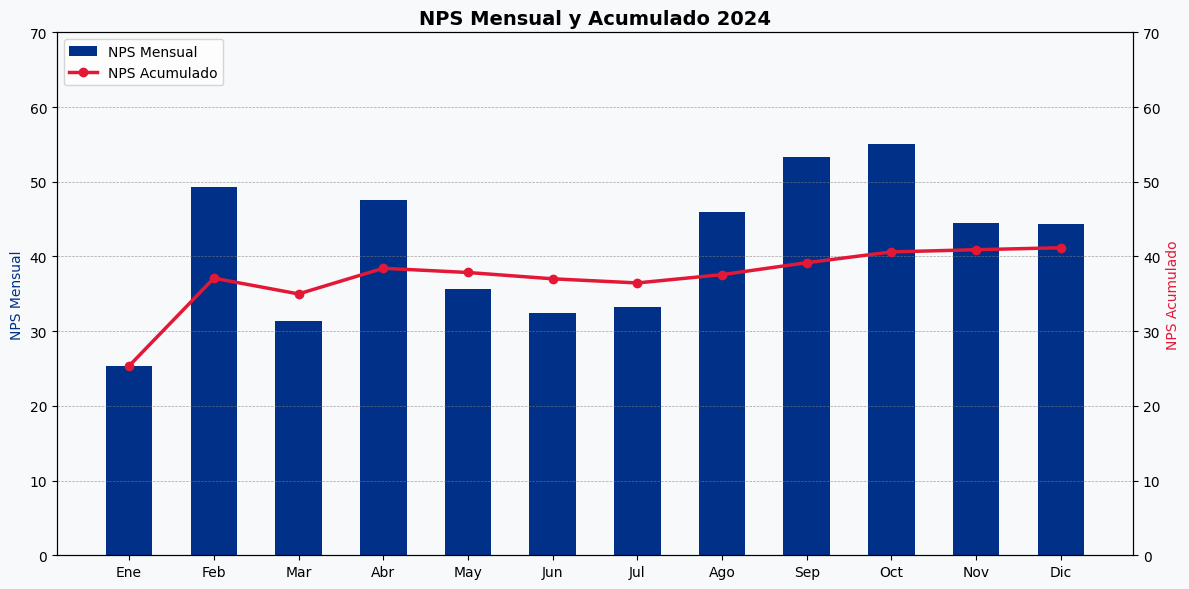

In [ ]:
import matplotlib.pyplot as plt

# Colores
COLOR_BAR = '#003087'
COLOR_LINE = '#E31837'
COLOR_BG = '#F8F9FA'

# Crear figura
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(COLOR_BG)
ax1.set_facecolor(COLOR_BG)

# Barras NPS mensual
bars = ax1.bar(nps_final['mes_nombre'], nps_final['NPS'], color=COLOR_BAR, width=0.55, label='NPS Mensual')

# Segundo eje para la línea acumulada
ax2 = ax1.twinx()
ax2.plot(nps_final['mes_nombre'], nps_final['NPS_acumulado'],
         color=COLOR_LINE, linewidth=2.5, marker='o', label='NPS Acumulado')


# Títulos y etiquetas
ax1.set_title('NPS Mensual y Acumulado 2024', fontsize=14, fontweight='bold')
ax1.set_ylabel('NPS Mensual', color=COLOR_BAR)
ax2.set_ylabel('NPS Acumulado', color=COLOR_LINE)

# Misma escala en ambos ejes
ax1.set_ylim(0, 70)
ax2.set_ylim(0, 70)
# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# Guardar y mostrar
plt.tight_layout()
plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('nps_mensual_acumulado.png', dpi=150)
plt.show()

### El NPS mensual y acumulado separando vuelos On Time y Service Recovery.

In [ ]:
# Clasificar vuelo en on time y service Recovery
def clasificar_vuelo(mins_demora_salida):
    if mins_demora_salida <= 15:
        return 'On Time'
    else:
        return 'Service Recovery'

df['tipo_vuelo'] = df['mins_demora_salida'].apply(clasificar_vuelo)

**NPS mensual separado por vuelos on time y service recovery**

In [ ]:

nps_ontime = df[df["tipo_vuelo"] == "On Time"].groupby('mes').apply(calcular_nps).reset_index()
nps_ontime.columns = ['mes', 'NPS On time']

nps_demoras = df[df["tipo_vuelo"] == 'Service Recovery'].groupby('mes').apply(calcular_nps).reset_index()
nps_demoras.columns = ['mes', 'NPS Service Recovery']

nps_mes_demorasyontime = nps_ontime.merge(nps_demoras, on='mes')

nps_mes_demorasyontime['mes_nombre'] = nps_mes_demorasyontime['mes'].map(meses_nombre)
print(nps_mes_demorasyontime)

    mes  NPS On time  NPS Service Recovery mes_nombre
0     1    35.174419              3.267974        Ene
1     2    53.935185              6.382979        Feb
2     3    40.570175             -9.708738        Mar
3     4    52.965235             17.241379        Abr
4     5    44.320713             -1.941748        May
5     6    39.895013              4.807692        Jun
6     7    46.192893             -2.816901        Jul
7     8    50.738916             22.619048        Ago
8     9    59.478673              1.960784        Sep
9    10    59.338061             10.000000        Oct
10   11    54.107649             -2.777778        Nov
11   12    56.873315             -5.319149        Dic


/tmp/ipykernel_35689/4211846915.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nps_ontime = df[df["tipo_vuelo"] == "On Time"].groupby('mes').apply(calcular_nps).reset_index()
/tmp/ipykernel_35689/4211846915.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nps_demoras = df[df["tipo_vuelo"] == 'Service Recovery'].groupby('mes').apply(calcular_nps).reset_index()


**NPS acumulado separado por vuelos on time y service recovery**

In [ ]:
#  NPS acumulado  vuelos a timepo y con demoras

nps_acumulado_ontime = []
nps_acumulado_demoras =[]

for mes in sorted(df["mes"].unique()):
    subset_ontime = df[(df["mes"] <= mes) & (df["tipo_vuelo"] == "On Time")]
    subset_demoras = df[(df["mes"] <= mes) & (df["tipo_vuelo"] == "Service Recovery")]

    nps_acumulado_ontime.append({"mes": mes, "NPS_acumulado_ontime": calcular_nps(subset_ontime)})
    nps_acumulado_demoras.append({"mes": mes, "NPS_acumulado_demoras": calcular_nps(subset_demoras)})

nps_acumulado_ontime = pd.DataFrame(nps_acumulado_ontime)
nps_acumulado_demoras = pd.DataFrame(nps_acumulado_demoras)
nps_acumulado_final = nps_acumulado_ontime.merge(nps_acumulado_demoras, on="mes")


In [ ]:
nps_acumulado_final['mes_nombre'] = nps_acumulado_final['mes'].map(meses_nombre)
print(nps_acumulado_final)

    mes  NPS_acumulado_ontime  NPS_acumulado_demoras mes_nombre
0     1             35.174419               3.267974        Ene
1     2             45.618557               4.000000        Feb
2     3             43.750000              -0.660066        Mar
3     4             46.368390               3.333333        Abr
4     5             45.944700               2.231237        May
5     6             45.041160               2.680067        Jun
6     7             45.195246               1.623816        Jul
7     8             45.866905               3.766707        Ago
8     9             47.389345               3.661327        Sep
9    10             48.593899               3.938731        Oct
10   11             49.021763               3.448276        Nov
11   12             49.613821               2.685185        Dic


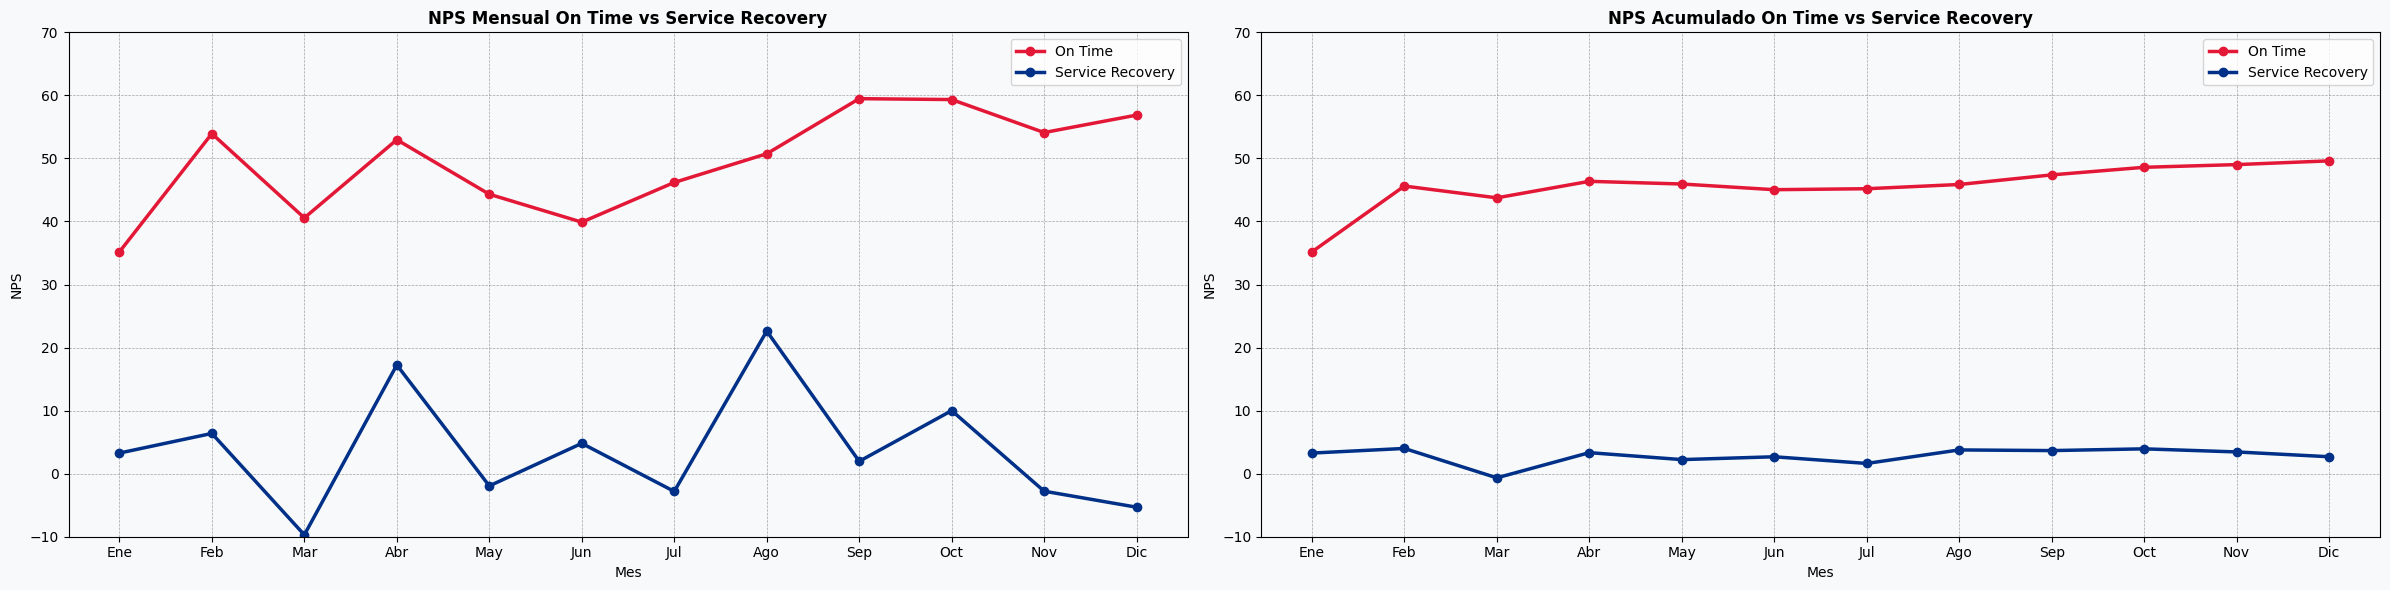

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6))
fig.patch.set_facecolor(COLOR_BG)
axs[0].set_facecolor(COLOR_BG)
axs[1].set_facecolor(COLOR_BG)

#  NPS Mensual
y0 = nps_mes_demorasyontime['mes_nombre']
axs[0].plot(y0, nps_mes_demorasyontime["NPS On time"],color=COLOR_LINE, linewidth=2.5, marker='o', label='On Time')
axs[0].plot(y0, nps_mes_demorasyontime['NPS Service Recovery'],color=COLOR_BAR, linewidth=2.5, marker='o', label='Service Recovery')

axs[0].set_title('NPS Mensual On Time vs Service Recovery', fontweight='bold')
axs[0].set_ylim(-10, 70)
axs[0].legend()
axs[0].grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0].set_ylabel("NPS")
axs[0].set_xlabel("Mes")



# NPS Acumulado
y1 = nps_acumulado_final['mes_nombre']
axs[1].plot(y1, nps_acumulado_final['NPS_acumulado_ontime'],color=COLOR_LINE, linewidth=2.5, marker='o', label='On Time')
axs[1].plot(y1, nps_acumulado_final['NPS_acumulado_demoras'],color=COLOR_BAR, linewidth=2.5, marker='o', label='Service Recovery')

axs[1].set_title('NPS Acumulado On Time vs Service Recovery', fontweight='bold')
axs[1].set_ylim(-10, 70)
axs[1].legend()
axs[1].grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axs[1].set_ylabel("NPS")
axs[1].set_xlabel("Mes")



plt.tight_layout()
plt.savefig('nps_tipo_vuelo.png', dpi=150)
plt.show()


### El Pulso score de los atributos de satisfacción para cada una de las regiones.

In [ ]:
def calcular_pulso(serie):
    ponderacion = {5: 1, 4: 0.5, 3: 0, 2: -0.5, 1: -2}
    serie_limpia = serie.dropna()
    if len(serie_limpia) == 0:
        return None
    return serie_limpia.map(ponderacion).sum() / len(serie_limpia)

In [ ]:
csats = ["csat_checkin", "csat_abordaje", "csat_tripulacion", "csat_comodidad_asientos", "csat_limpieza_cabina", "csat_alimentos",
         "csat_entretenimiento", "csat_entrega_equipaje", "csat_conexion", "csat_manejo_demora"]
pulso_region = pd.DataFrame()
for i in csats:
  pulso_region[i] = df.groupby('Region_ruta')[i].apply(calcular_pulso)
pulso_region

,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora
Region_ruta,,,,,,,,,,
Europa-Asia,0.739857,0.666667,0.660000,0.452539,0.769401,0.459459,0.613300,0.436860,0.544944,-0.287234
LATAM,0.689619,0.648421,0.679957,0.427957,0.718750,0.289532,0.448127,0.426136,0.464497,-0.237500
Nacional,0.718870,0.650597,0.754223,0.629766,0.789679,0.336655,0.504151,0.563291,0.545940,-0.314815
Norte America,0.598925,0.551432,0.687836,0.455580,0.696544,0.311277,0.550633,0.329146,0.337156,-0.082090


In [ ]:
nombres_csats = {
    "csat_checkin": "Check-in",
    "csat_abordaje": "Abordaje",
    "csat_tripulacion": "Tripulación",
    "csat_comodidad_asientos": "Comodidad Asientos",
    "csat_limpieza_cabina": "Limpieza Cabina",
    "csat_alimentos": "Alimentos",
    "csat_entretenimiento": "Entretenimiento",
    "csat_entrega_equipaje": "Entrega Equipaje",
    "csat_conexion": "Conexión",
    "csat_manejo_demora": "Manejo Demora"
}
pulso_region = pulso_region.rename(columns=nombres_csats)

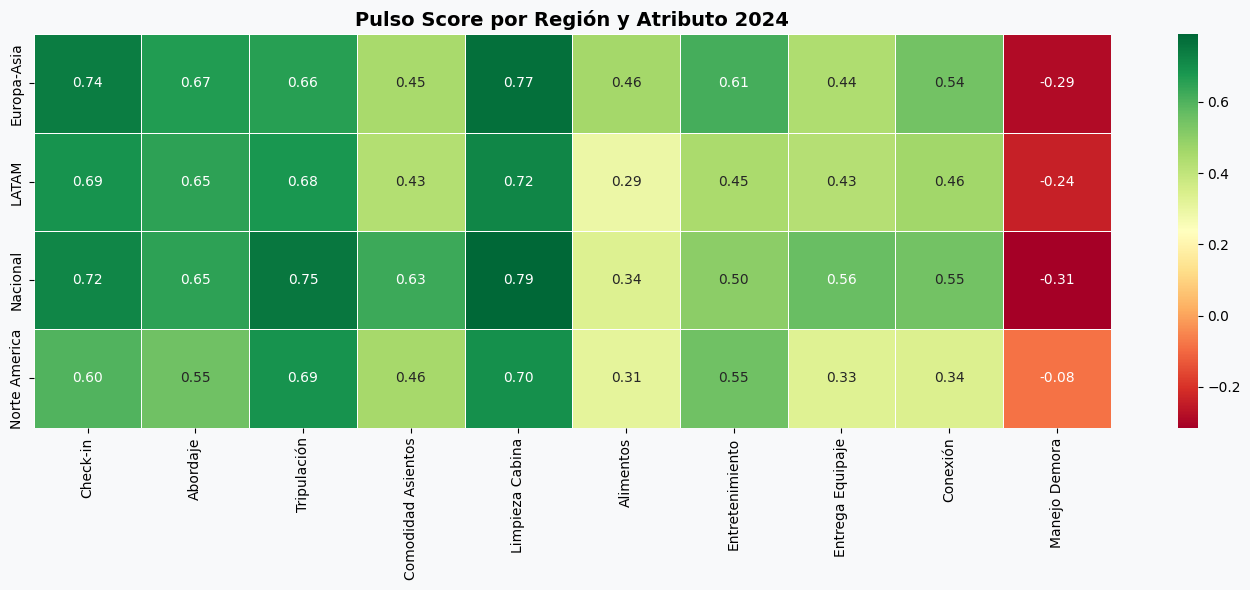

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

sns.heatmap(
    pulso_region,           # dataframe con regiones en filas y atributos en columnas
    annot=True,             # muestra los valores dentro de cada celda
    fmt='.2f',              # formato de los valores con 2 decimales
    cmap='RdYlGn',          # colores: rojo = bajo, amarillo = medio, verde = alto
    linewidths=0.5,         # líneas entre celdas
)

ax.set_title('Pulso Score por Región y Atributo 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')


plt.tight_layout()
plt.savefig('pulso_region.png', dpi=150)
plt.show()

### El Pulso score del atributo de Check-in para clientes que hacen check-in en MEX por cada uno de los canales de Check-in.

In [ ]:
# Filtrar clientes que hacen check-in en MEX
df_mex = df[df['ato_checkin'] == 'MEX']

# Calcular Pulso de check-in por canal
pulso_checkin = df_mex.groupby('canalcheckin')['csat_checkin'].apply(calcular_pulso).reset_index()
pulso_checkin.columns = ['Canal', 'Pulso_Checkin']

pulso_checkin

,Canal,Pulso_Checkin
0,Aplicación movil,0.591797
1,Mostrador,0.294595
2,Página Web,0.700642
3,Quiosco,0.712121


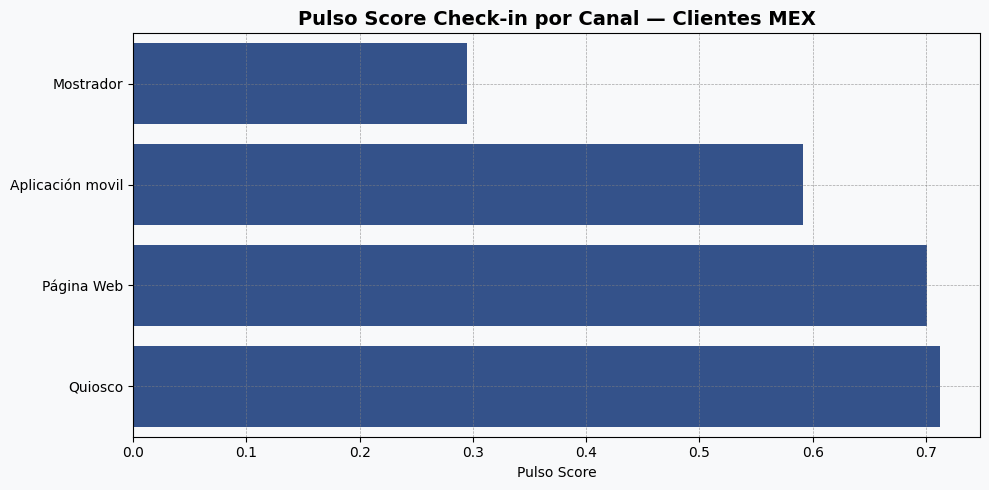

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)


pulso_checkin_sorted = pulso_checkin.sort_values('Pulso_Checkin', ascending=True)


sns.barplot(data=pulso_checkin_sorted, y='Canal', x='Pulso_Checkin',
            color=COLOR_BAR, alpha=0.85, ax=ax)

ax.set_title('Pulso Score Check-in por Canal — Clientes MEX', fontsize=14, fontweight='bold')
ax.set_xlabel('Pulso Score')
ax.set_ylabel('')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()
plt.savefig('pulso_checkin_canal.png', dpi=150)
plt.show()

### El Pulso score de los atributos de Comodidad de asientos, Limpieza de cabina y Entretenimiento para cada tipo de equipo.

In [ ]:
csats_avion = ["csat_comodidad_asientos", "csat_limpieza_cabina", "csat_entretenimiento"]

pulso_equipo = pd.DataFrame()
for i in csats_avion:
  pulso_equipo[i] = df.groupby('equipo')[i].apply(calcular_pulso)

pulso_equipo = pulso_equipo.rename(columns={
    "csat_comodidad_asientos": "Comodidad Asientos",
    "csat_limpieza_cabina": "Limpieza Cabina",
    "csat_entretenimiento": "Entretenimiento"
})
pulso_equipo

,Comodidad Asientos,Limpieza Cabina,Entretenimiento
equipo,,,
B737-8 MAX,0.475806,0.688000,0.020833
B737-800,0.564004,0.763043,0.531626
B787-800,0.353488,0.654206,0.492347
B787-900,0.521882,0.799781,0.647727
E190,0.585925,0.759836,0.276243


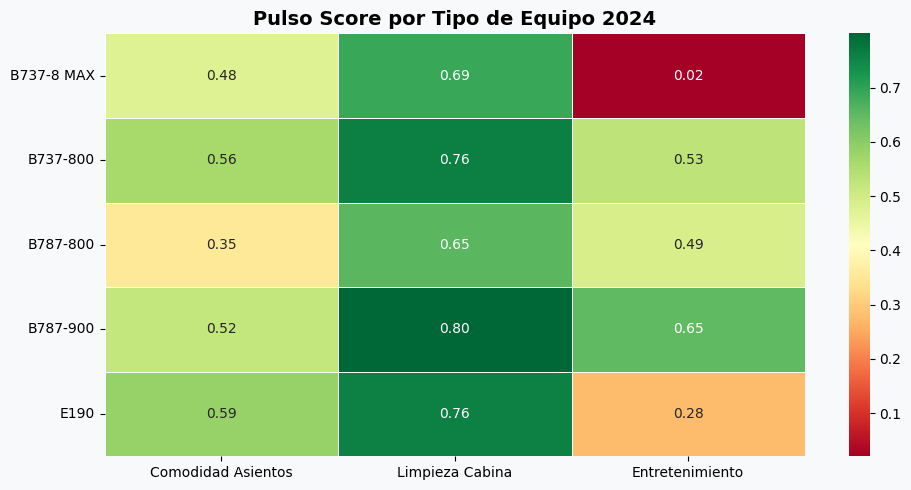

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

sns.heatmap(
    pulso_equipo,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,

)

ax.set_title('Pulso Score por Tipo de Equipo 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('pulso_equipo.png', dpi=150)
plt.show()

### El Pulso score de Entrega de Equipaje de los clientes que recogen en MEX.

In [ ]:
df_recogen_mex = df[df['ato_equipaje'] == 'MEX']

pulso_equipaje = calcular_pulso(df_recogen_mex['csat_entrega_equipaje'])
pulso_equipaje



np.float64(0.3231631382316314)

In [ ]:
pulso_equipaje_region = (
    df.groupby('Region_ruta')['csat_entrega_equipaje']
    .apply(calcular_pulso)
    .sort_values()
)

pulso_equipaje_region = pd.DataFrame(pulso_equipaje_region)

pulso_equipaje_region.columns = ["Pulso_score"]

pulso_equipaje_region = pulso_equipaje_region.reset_index()

pulso_equipaje_region

,Region_ruta,Pulso_score
0,Norte America,0.329146
1,LATAM,0.426136
2,Europa-Asia,0.436860
3,Nacional,0.563291


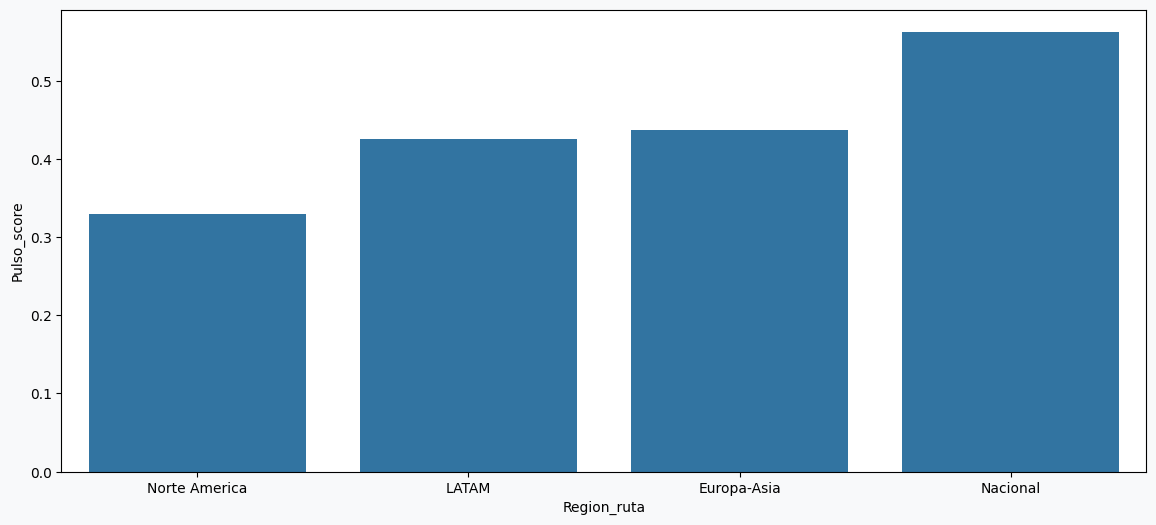

In [ ]:
fig, axs = plt.subplots( figsize=(14, 6))
fig.patch.set_facecolor(COLOR_BG)
sns.barplot(data=pulso_equipaje_region, x="Region_ruta", y="Pulso_score")
plt.savefig('equipaje_region.png', dpi=150)

### Los principales temas que comentan los clientes.

In [ ]:
import re
from collections import Counter

In [ ]:
palabras_noimpoertantes_español = ['de', 'la', 'el', 'en', 'y', 'a', 'que', 'los', 'las', 'un', 'una',
             'por', 'con', 'se', 'su', 'es', 'fue', 'muy', 'me', 'mi', 'lo',
             'al', 'del', 'les', 'le', 'si', 'no', 'más', 'pero', 'como', 'para', "solo", "tenia", "tuve",
             'todo', 'este', 'esta', 'son', 'hay', 'han', 'ser', 'fue', 'era', "porque", "nos", "mas", "cuando", "nada", "estaba", "sin", "habia"]
palabras_noimpoertantes_inglés = ['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
                'for', 'of', 'with', 'was', 'is', 'it', 'i', 'my', 'me', 'we',
                'they', 'he', 'she', 'very', 'not', 'no', 'be', 'been', 'have',
                'had', 'this', 'that', 'all', 'from', 'by', 'as', 'are', 'were']

palabras_noimportantes = palabras_noimpoertantes_español + palabras_noimpoertantes_inglés

In [ ]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return ''
    texto=str(texto)
    texto = texto.lower()                        # minúsculas
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)  # quitar puntuación y números
    palabras = texto.split()
    palabras_filtradas=[]
    for i in palabras:
      if i not in palabras_noimportantes and len(i) > 2:
        palabras_filtradas.append(i)
    return ' '.join(palabras_filtradas)

In [ ]:
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto)

Identificar los temas mas comentados por detractores y promotores

In [ ]:
comentarios_promotor = df[df['tipo_cliente'] == 'promotor']['comentario_limpio']
comentarios_detractor = df[df['tipo_cliente'] == 'detractor']['comentario_limpio']

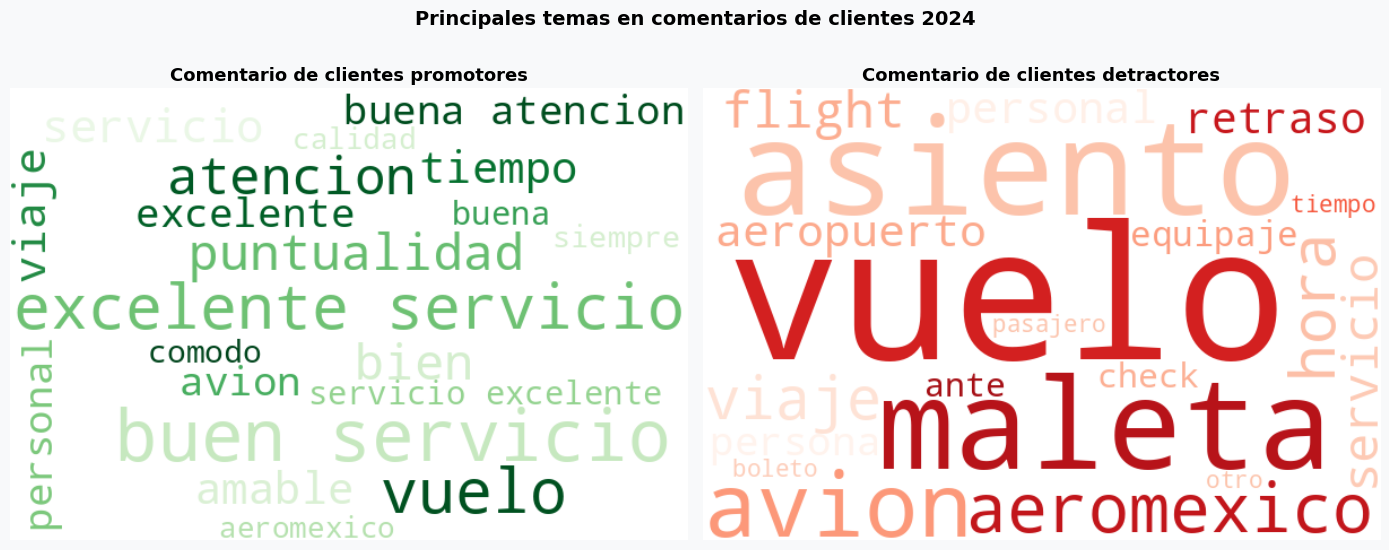

In [ ]:
from wordcloud import WordCloud

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(COLOR_BG)

# Unir todos los comentarios en un solo texto
texto_promotor = ' '.join(comentarios_promotor.dropna())
texto_detractor = ' '.join(comentarios_detractor.dropna())

# Nube promotores
wordcloud_promotor = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Greens',          # colores verdes para positivos
    max_words=20
).generate(texto_promotor)

axs[0].imshow(wordcloud_promotor, interpolation='bilinear')
axs[0].set_title('Comentario de clientes promotores', fontsize=13, fontweight='bold')
axs[0].axis('off')              # quita los ejes, no tienen sentido en una nube

# Nube detractores
wordcloud_detractor = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Reds',            # colores rojos para negativos
    max_words=20
).generate(texto_detractor)

axs[1].imshow(wordcloud_detractor, interpolation='bilinear')
axs[1].set_title('Comentario de clientes detractores', fontsize=13, fontweight='bold')
axs[1].axis('off')

plt.suptitle('Principales temas en comentarios de clientes 2024',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nube_palabras.png', dpi=150)
plt.show()

## 3. Modelos analisis  

In [ ]:
df.head()

,fecha,surveyid,ato_origen,ato_destino,ato_conexion,ato_checkin,ato_equipaje,numerovuelo,carrier,equipo,...,csat_entretenimiento,csat_entrega_equipaje,csat_conexion,csat_manejo_demora,Ruta,Region_ruta,mes,tipo_cliente,tipo_vuelo,comentario_limpio
0,2024-08-14,70072332,ORD,MEX,NaN,ORD,MEX,683,AM,B737-800,...,5.0,5.0,NaN,NaN,ORDMEX,Norte America,8,promotor,On Time,gran calidad servicio confiabilidad
1,2024-04-21,65183802,MEX,FCO,FCO,MEX,NaN,70,AM,B787-800,...,3.0,NaN,5.0,NaN,MEXFCO,Europa-Asia,4,promotor,On Time,
2,2024-09-12,71347018,LAX,GDL,NaN,LAX,GDL,783,AM,B737-800,...,5.0,5.0,NaN,NaN,LAXGDL,Norte America,9,promotor,On Time,
3,2024-06-18,67680750,MEX,ORD,NaN,MEX,ORD,1686,AM,B737-800,...,NaN,NaN,NaN,NaN,MEXORD,Norte America,6,promotor,On Time,amables puntual salidas
4,2024-08-17,70239655,CUN,MEX,NaN,CUN,MEX,551,AM,B737-800,...,5.0,5.0,NaN,NaN,CUNMEX,Nacional,8,promotor,On Time,


In [ ]:
csats = ['csat_checkin', 'csat_abordaje', 'csat_tripulacion', 'csat_comodidad_asientos',
         'csat_limpieza_cabina', 'csat_alimentos', 'csat_entretenimiento',
         'csat_entrega_equipaje']

df_regresion = df[['ltr'] + csats].copy()

In [ ]:
 !pip install scikit-learn

In [ ]:
from sklearn.impute import KNNImputer

# Crear el imputador con 5 vecinos
imputer = KNNImputer(n_neighbors=5)

# Aplicar solo a las columnas csat
df_regresion[csats] = imputer.fit_transform(df_regresion[csats])

print(df_regresion.isnull().sum())


ltr                        0
csat_checkin               0
csat_abordaje              0
csat_tripulacion           0
csat_comodidad_asientos    0
csat_limpieza_cabina       0
csat_alimentos             0
csat_entretenimiento       0
csat_entrega_equipaje      0
dtype: int64


KNN Imputer en lugar de poner un valor genérico como la media general, buscó clientes con un perfil parecido y usó su experiencia para estimar lo que ese cliente probablemente hubiera respondido.

In [ ]:
df_regresion.head()

,ltr,csat_checkin,csat_abordaje,csat_tripulacion,csat_comodidad_asientos,csat_limpieza_cabina,csat_alimentos,csat_entretenimiento,csat_entrega_equipaje
0,5,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,5,5.0,5.0,4.0,3.0,5.0,3.0,3.0,4.2
2,5,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,5,5.0,5.0,5.0,5.0,5.0,4.0,4.8,4.2
4,5,5.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0


### Regresion lineal multiple

In [ ]:
 # SEparar variables
Y = df_regresion['ltr']

X = df_regresion[csats]

print(X.shape)
print(Y.shape)

(6000, 8)
(6000,)


In [ ]:
import statsmodels.api as sm

# Agregar constante
X_const = sm.add_constant(X)

# Correr la regresión
modelo = sm.OLS(Y, X_const).fit()

# Ver resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    ltr   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     452.2
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        14:08:24   Log-Likelihood:                -8732.4
No. Observations:                6000   AIC:                         1.748e+04
Df Residuals:                    5991   BIC:                         1.754e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
nombres = {
    'csat_checkin': 'Check-in',
    'csat_abordaje': 'Abordaje',
    'csat_tripulacion': 'Tripulación',
    'csat_comodidad_asientos': 'Comodidad Asientos',
    'csat_limpieza_cabina': 'Limpieza Cabina',
    'csat_alimentos': 'Alimentos',
    'csat_entretenimiento': 'Entretenimiento',
    'csat_entrega_equipaje': 'Entrega Equipaje'
}

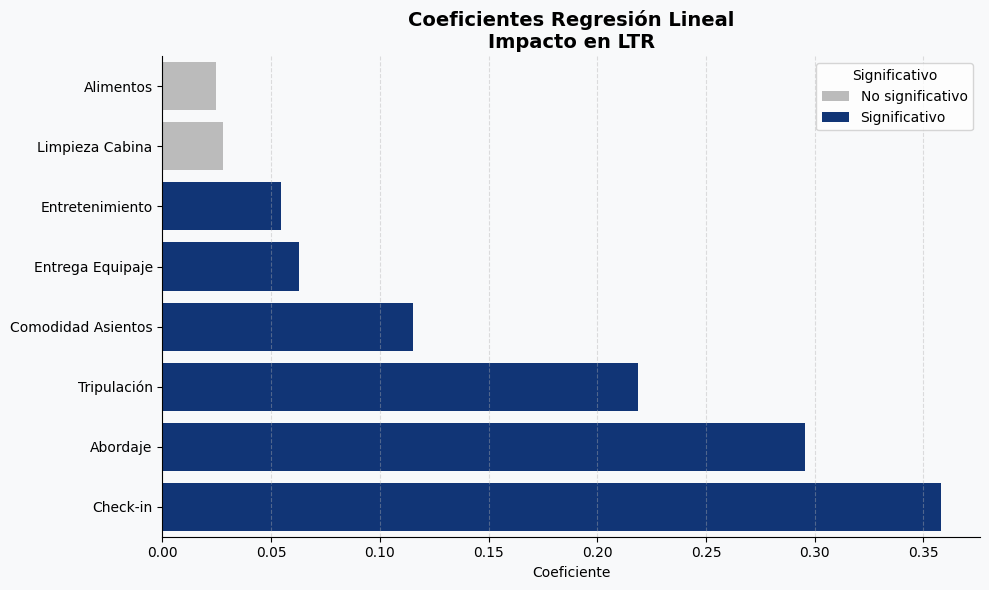

In [ ]:
# Preparar datos
resultados_reg = pd.DataFrame({
    'Atributo': csats,
    'Coeficiente': modelo.params[1:].values,
    'P_value': modelo.pvalues[1:].values
})
resultados_reg = resultados_reg.sort_values('Coeficiente', ascending=True)
resultados_reg['Significativo'] = resultados_reg['P_value'].apply(
    lambda x: 'Significativo' if x < 0.05 else 'No significativo'
)
resultados_reg['Atributo'] = resultados_reg['Atributo'].map(nombres)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

sns.barplot(data=resultados_reg, y='Atributo', x='Coeficiente',
            hue='Significativo',
            palette={'Significativo': COLOR_BAR, 'No significativo': '#BBBBBB'},
            ax=ax)

ax.set_title('Coeficientes Regresión Lineal\nImpacto en LTR',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('coeficientes_regresion.png', dpi=150)
plt.show()


### Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Usar el mismo dataframe de la regresión
X_rf = df_regresion[csats]
Y_rf = df_regresion['ltr']

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, Y_train, Y_test = train_test_split(X_rf, Y_rf, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
Y_pred = rf.predict(X_test)
r2 = r2_score(Y_test, Y_pred)
print(f'R² Random Forest: {r2:.4f}')
print(f'R² Regresión lineal: 0.376')

R² Random Forest: 0.3718
R² Regresión lineal: 0.376


In [ ]:
importancia = pd.DataFrame({
    'Atributo': csats,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancia)

                  Atributo  Importancia
0             csat_checkin     0.340493
1            csat_abordaje     0.215859
2         csat_tripulacion     0.157314
7    csat_entrega_equipaje     0.072205
6     csat_entretenimiento     0.063032
3  csat_comodidad_asientos     0.056485
5           csat_alimentos     0.052720
4     csat_limpieza_cabina     0.041893


### Regresion nominal

In [ ]:
!pip install statsmodels

from statsmodels.miscmodels.ordinal_model import OrderedModel

# Usar el dataframe con imputación KNN
modelo_ordinal = OrderedModel(Y_rf, X_rf, distr='logit')
resultado_ordinal = modelo_ordinal.fit(method='bfgs')
print(resultado_ordinal.summary())

Optimization terminated successfully.
         Current function value: 0.936783
         Iterations: 42
         Function evaluations: 44
         Gradient evaluations: 44
                             OrderedModel Results                             
Dep. Variable:                    ltr   Log-Likelihood:                -5620.7
Model:                   OrderedModel   AIC:                         1.127e+04
Method:            Maximum Likelihood   BIC:                         1.135e+04
Date:                Thu, 21 May 2026                                         
Time:                        14:08:45                                         
No. Observations:                6000                                         
Df Residuals:                    5988                                         
Df Model:                           8                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------